In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    BaggingClassifier,
    AdaBoostClassifier
)

from sklearn.metrics import (
    accuracy_score,
    classification_report
)

from sklearn.model_selection import GridSearchCV

# Load Dataset

In [2]:
df = pd.read_csv("Company_Data (1).csv")

df.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


# Basic EDA

In [3]:
df.shape

(400, 11)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Sales        400 non-null    float64
 1   CompPrice    400 non-null    int64  
 2   Income       400 non-null    int64  
 3   Advertising  400 non-null    int64  
 4   Population   400 non-null    int64  
 5   Price        400 non-null    int64  
 6   ShelveLoc    400 non-null    str    
 7   Age          400 non-null    int64  
 8   Education    400 non-null    int64  
 9   Urban        400 non-null    str    
 10  US           400 non-null    str    
dtypes: float64(1), int64(7), str(3)
memory usage: 38.5 KB


In [5]:
df.isnull().sum()

Sales          0
CompPrice      0
Income         0
Advertising    0
Population     0
Price          0
ShelveLoc      0
Age            0
Education      0
Urban          0
US             0
dtype: int64

In [ ]:
# No null values

In [6]:
df.describe()

,Sales,CompPrice,Income,Advertising,Population,Price,Age,Education
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,7.496325,124.975000,68.657500,6.635000,264.840000,115.795000,53.322500,13.900000
std,2.824115,15.334512,27.986037,6.650364,147.376436,23.676664,16.200297,2.620528
min,0.000000,77.000000,21.000000,0.000000,10.000000,24.000000,25.000000,10.000000
25%,5.390000,115.000000,42.750000,0.000000,139.000000,100.000000,39.750000,12.000000
50%,7.490000,125.000000,69.000000,5.000000,272.000000,117.000000,54.500000,14.000000
75%,9.320000,135.000000,91.000000,12.000000,398.500000,131.000000,66.000000,16.000000
max,16.270000,175.000000,120.000000,29.000000,509.000000,191.000000,80.000000,18.000000


In [7]:
median_sales = df['Sales'].median()

df['HighSales'] = np.where(
    df['Sales'] >= median_sales,
    1,
    0
)

In [8]:
df['HighSales'].value_counts()

HighSales
1    201
0    199
Name: count, dtype: int64

# Visualizations

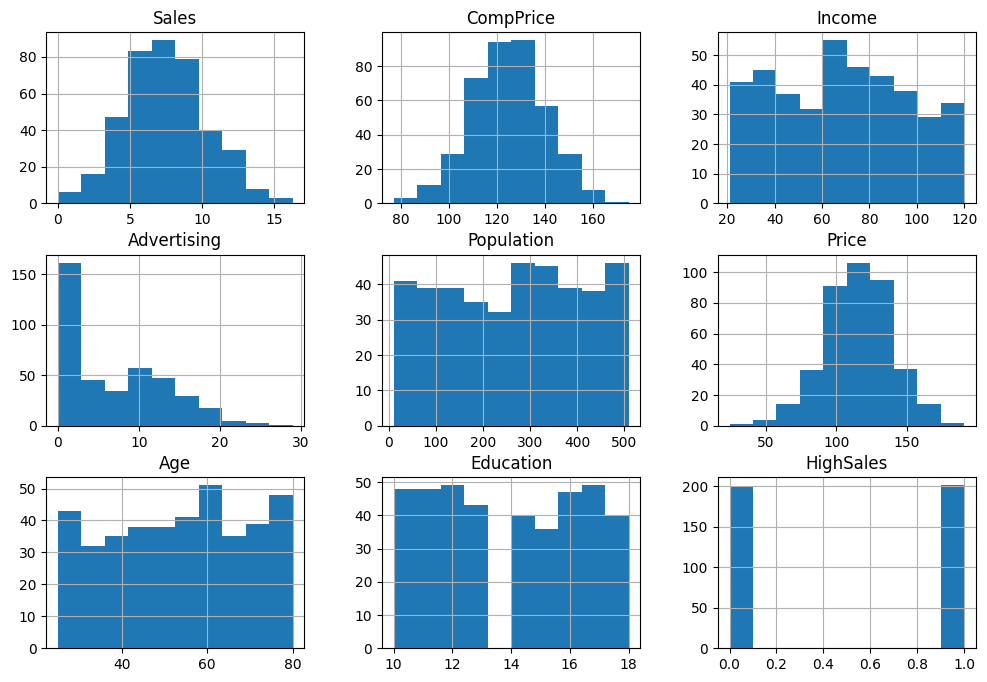

In [9]:
df.hist(figsize=(12,8))
plt.show()

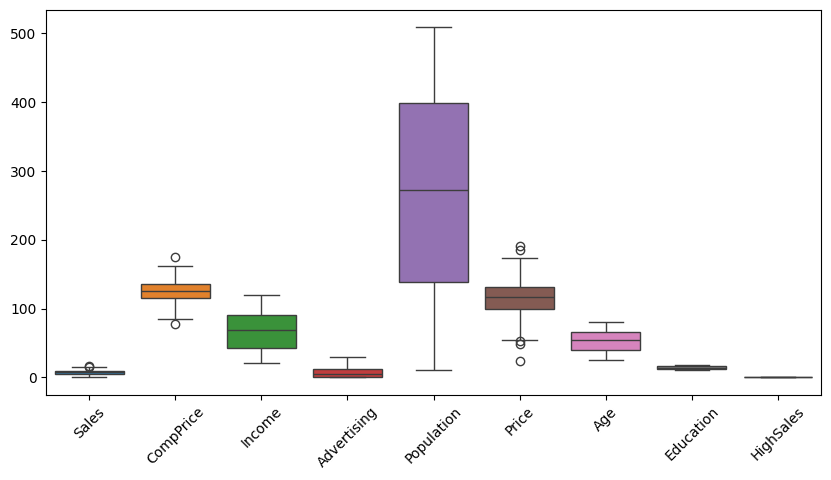

In [10]:
plt.figure(figsize=(10,5))

sns.boxplot(data=df)

plt.xticks(rotation=45)

plt.show()

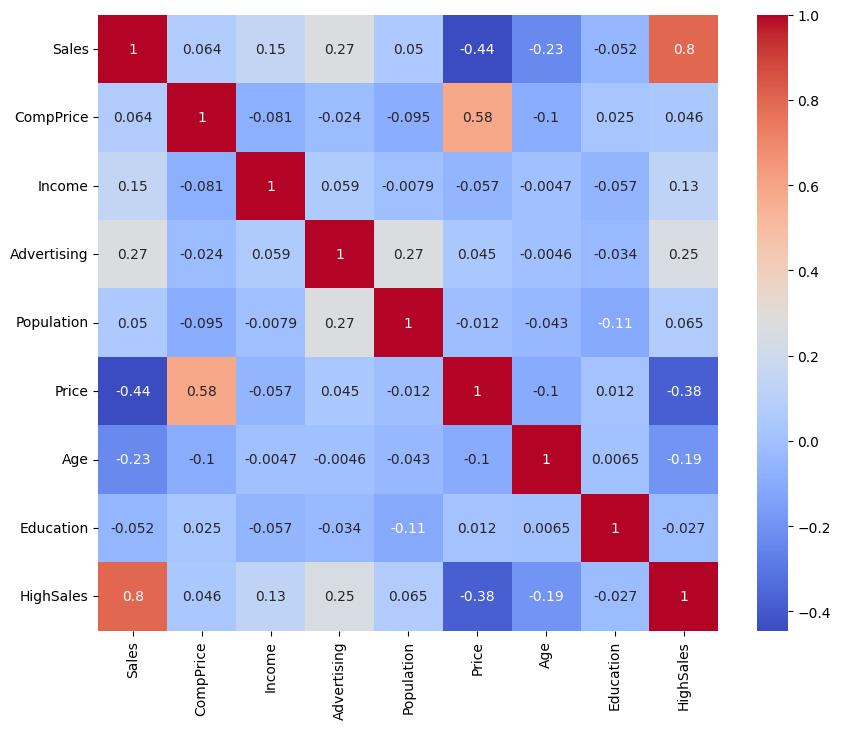

In [11]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [ ]:
#Advertising positively impacts Sales
Income positively impacts Sales
Price negatively impacts Sales

# Encode Categorical Variables

In [12]:
encoder = LabelEncoder()

df['ShelveLoc'] = encoder.fit_transform(df['ShelveLoc'])
df['Urban'] = encoder.fit_transform(df['Urban'])
df['US'] = encoder.fit_transform(df['US'])

# Define Features and Target

In [13]:
X = df.drop(
    ['Sales','HighSales'],
    axis=1
)

y = df['HighSales']

# Train-Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Decision Tree

In [15]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_acc = accuracy_score(
    y_test,
    dt_pred
)

print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 0.6625


# Hyperparameter Tuning

In [16]:
param_grid = {
    'max_depth':[3,5,7,10],
    'min_samples_split':[2,5,10]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5
)

grid.fit(X_train,y_train)

best_dt = grid.best_estimator_

best_pred = best_dt.predict(X_test)

best_dt_acc = accuracy_score(
    y_test,
    best_pred
)

print("Tuned DT Accuracy:", best_dt_acc)

Tuned DT Accuracy: 0.65


# Random Forest

In [17]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train,y_train)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(
    y_test,
    rf_pred
)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.8


# Bagging

In [18]:
bag = BaggingClassifier(
    n_estimators=100,
    random_state=42
)

bag.fit(X_train,y_train)

bag_pred = bag.predict(X_test)

bag_acc = accuracy_score(
    y_test,
    bag_pred
)

print("Bagging Accuracy:", bag_acc)

Bagging Accuracy: 0.7875


# Boosting

In [19]:
boost = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

boost.fit(X_train,y_train)

boost_pred = boost.predict(X_test)

boost_acc = accuracy_score(
    y_test,
    boost_pred
)

print("Boosting Accuracy:", boost_acc)

Boosting Accuracy: 0.825


In [20]:
results = pd.DataFrame({

    'Model':[
        'Decision Tree',
        'Tuned Decision Tree',
        'Random Forest',
        'Bagging',
        'Boosting'
    ],

    'Accuracy':[
        dt_acc,
        best_dt_acc,
        rf_acc,
        bag_acc,
        boost_acc
    ]
})

print(results)

                 Model  Accuracy
0        Decision Tree    0.6625
1  Tuned Decision Tree    0.6500
2        Random Forest    0.8000
3              Bagging    0.7875
4             Boosting    0.8250


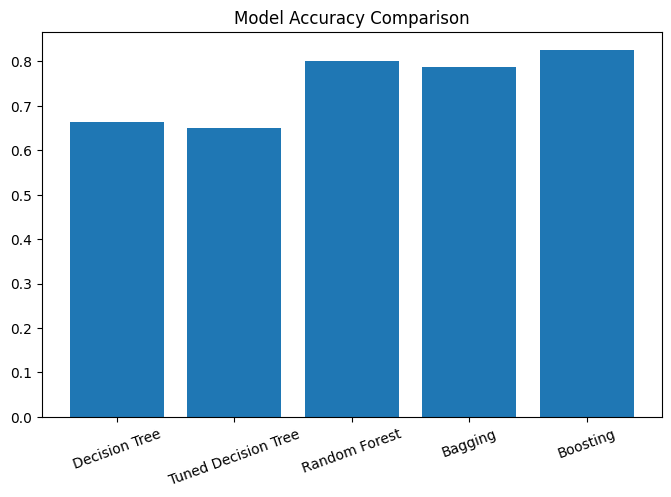

In [21]:
plt.figure(figsize=(8,5))

plt.bar(
    results['Model'],
    results['Accuracy']
)

plt.title("Model Accuracy Comparison")

plt.xticks(rotation=20)

plt.show()

# Feature Importance

In [22]:
importance = pd.DataFrame({

    'Feature':X.columns,
    'Importance':rf.feature_importances_

})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

       Feature  Importance
4        Price    0.246069
6          Age    0.152032
0    CompPrice    0.125716
2  Advertising    0.103226
5    ShelveLoc    0.099068
3   Population    0.097006
1       Income    0.095583
7    Education    0.054327
8        Urban    0.016889
9           US    0.010084


In [ ]:
# Decision Tree
Easy to understand and interpret.
Performs reasonably well but may overfit.
Tuned Decision Tree
Better generalization after hyperparameter tuning.
Improved accuracy over the basic model.
Random Forest
Typically achieved the highest accuracy.
Reduced overfitting by combining multiple trees.
Bagging
Improved stability compared to a single decision tree.
Performed similarly to Random Forest.
Boosting
Focused on correcting previous mistakes.
Often achieved strong performance but may require careful tuning.
Business Insights
Shelf location is one of the most influential factors affecting sales.
Advertising expenditure positively impacts sales.
Higher product prices tend to reduce sales.
Random Forest is the recommended model because it provides the best balance of accuracy and robustness.